In [3]:
import pandas as pd
import numpy as np
import scipy.io as sio

import os.path
import time
import random
import math

In [4]:
def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

In [5]:
def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

In [6]:
def RevOneHotEncode(arr):
    seq2=""
    for i in arr:
        if (i[0] == 1):
            seq2+='A';
        elif (i[1] == 1):
            seq2+='C';
        elif (i[2] == 1):
            seq2+='G';
        elif (i[3] == 1):
            seq2+='T';
        else:
            seq2+='N';
    return seq2;

In [7]:
def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)

In [133]:
def min_max_norm(arr):
    new_arr = []
    min_v = min(arr)
    max_v = max(arr)
    for num in arr:
        new_arr=new_arr+[(num-min_v)/(max_v-min_v)]
    return(new_arr)
    

In [117]:
def SD_calculation(seq, tb, DNAshape):
    # print(tb.keys())'
    N=10 # calculate SD value for every 10 bps
    shape_values = []

    #Initial the first pentamer
    pentamer = RevOneHotEncode(seq[0:5])
    if pentamer not in tb.keys():
        pentamer = reverse_complement(pentamer)
    for i in range(len(DNAshape)):
        shape_values.append(tb.get(pentamer)[i])

    for i in range(1, len(seq)-5):
        pentamer = RevOneHotEncode(seq[i:i+5])
        if pentamer not in tb.keys():
            pentamer = reverse_complement(pentamer)
        else:
            for j in range(0, len(DNAshape)):
                shape_values[j] = shape_values[j] + tb.get(pentamer)[j]
    return shape_values;

In [9]:
def nucseq_shape_analysis(fname, out, DNAshape, tb):

    # Open and read file
    if os.path.isfile(fname):
        mat_contents = sio.loadmat(fname)
        edata=mat_contents['EnrichedData']
        ddata=mat_contents['DepletedData']
#     print(tb)

    shapes = []
    np_allEnrichSeqArr = np.array(edata)
    np_allDepleteSeqArr = np.array(ddata)
    print(f"3 np_allEnrichSeqArr.shape {np_allEnrichSeqArr.shape}, np_allDepleteSeqArr.shape {np_allDepleteSeqArr.shape}");
    for d in ddata:
        if 'N' not in d:
            shape_values = SD_calculation(d, tb, DNAshape)
            shapes.append(shape_values)

    string = ""
    for line in shapes:
        curr_str = " ".join(str(s) for s in line)
        string = string + curr_str + "\n"
    
    f = open(out, 'w+');
    f.write(string)
    f.write("\n")
    f.close()

In [195]:
def shape_param_analysis(tb):
    
    
#     intra_rot = [3:5]
#     inter_trans = [6:11]
#     inter_rot = [12:17]
#     GrooveWidth = [18:21]
    
#     intra_trans_SD = [22:24]
#     inter_trans_SD = [25:27]
#     intra_rot_SD = [28:30]
#     inter_rot_SD= [31:33]
#     GrooveWidth_SD = [34:37]


    all_shape_vals = []
    for pentamer in tb.keys():
        shape_vals = tb[pentamer]
        all_shape_vals+= [shape_vals]
    all_shape_vals2 = np.array(all_shape_vals).T
    all_norm_shape_vals = []
    
    # Perform per-shape normalization
    from sklearn import preprocessing
    for shape in all_shape_vals2:
        all_norm_shape_vals+= [min_max_norm(shape)]
#     print(np.array(all_norm_shape_vals).shape)
    return all_norm_shape_vals, all_shape_vals2;

In [209]:
intra_trans = list(range(0,3))
intra_rot = list(range(3,6))
inter_trans = list(range(6,12))
inter_rot = list(range(12,18))

GrooveWidth = list(range(18,22))
intra_trans_SD = list(range(22,25))
intra_rot_SD = list(range(25,28))
inter_trans_SD = list(range(28,31))
inter_rot_SD=  list(range(31,34))
GrooveWidth_SD = list(range(34,37))

All_params = [intra_trans, intra_rot,inter_trans,inter_rot,GrooveWidth,intra_trans_SD,inter_trans_SD,intra_rot_SD,inter_rot_SD,GrooveWidth_SD]

print(All_params)   

[[0, 1, 2], [3, 4, 5], [6, 7, 8, 9, 10, 11], [12, 13, 14, 15, 16, 17], [18, 19, 20, 21], [22, 23, 24], [28, 29, 30], [25, 26, 27], [31, 32, 33], [34, 35, 36]]


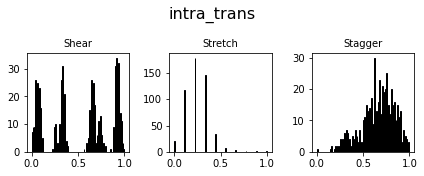

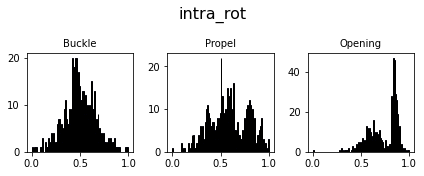

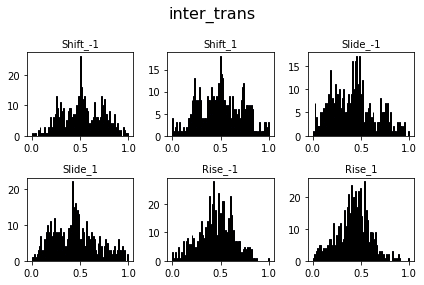

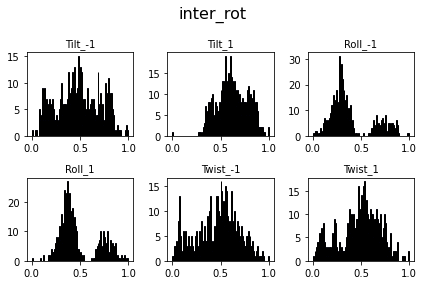

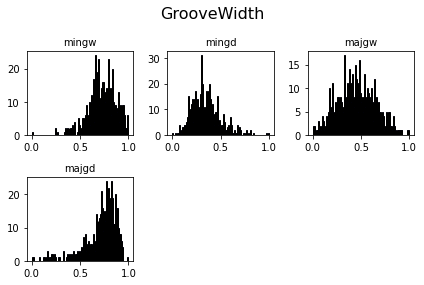

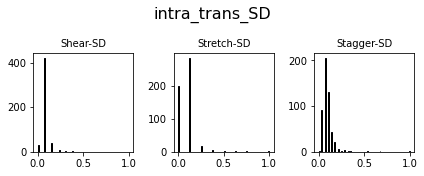

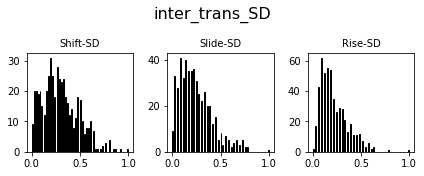

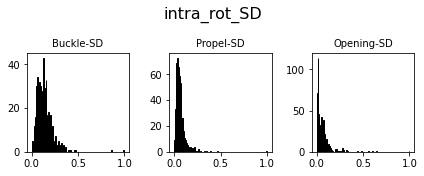

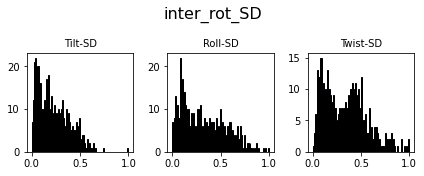

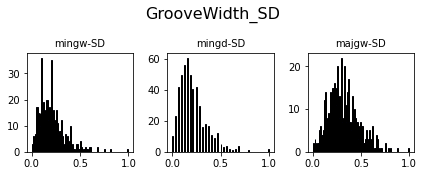

In [208]:
AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
            'Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
tb = read_SD_table(fileName);
    
##### 1
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)

# fig, axs = plt.subplots(1, 3, tight_layout=True)

# # N is the count in each bin, bins is the lower-limit of the bin

for i in range(len(All_params)):
    pic_index = All_params[i]
    fig = plt.figure()
    fig.suptitle(All_params_names[i], fontsize=16)

    for j in range(len(pic_index)):

        # Set up the plot
        row = len(All_params[i])/3
        ax = plt.subplot(2, 3, j+1)
    
        # Draw the plot
        x = all_norm_shape_vals[pic_index[j]]
        ax.hist(x, bins = 100,
                 color = 'blue', edgecolor = 'black')
    
        # Title and labels
        ax.set_title('%s' % AllDNAshape[pic_index[j]], size = 10)

    plt.tight_layout()
    plt.savefig(All_params_names[i]+".jpg")

##### 2
# fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/train_test_data/nucleosome_occupancy_30.mat'
# E_out = "Edata_SD_values.txt"
# D_out = "Ddata_SD_values.txt"

# nucseq_shape_analysis(fname, D_out, AllDNAshape[3:5], tb)

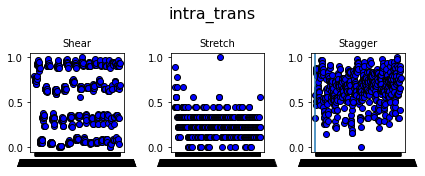

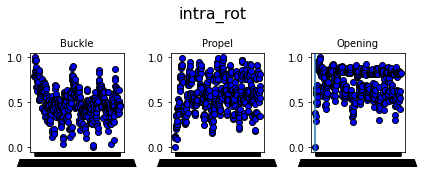

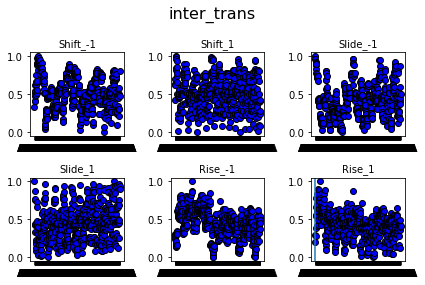

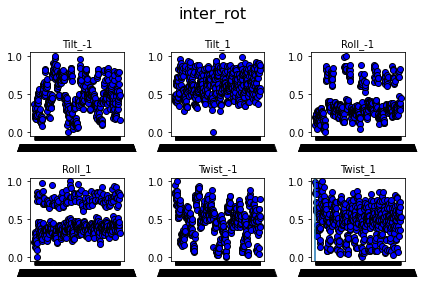

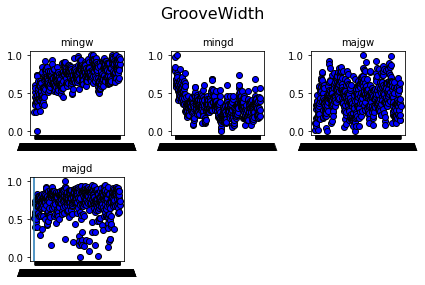

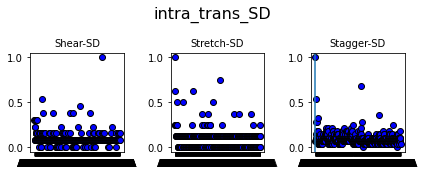

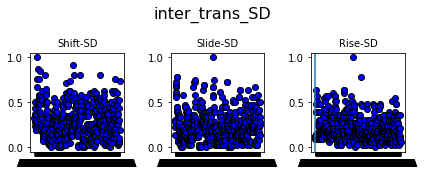

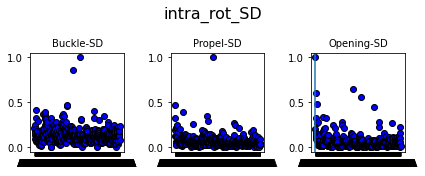

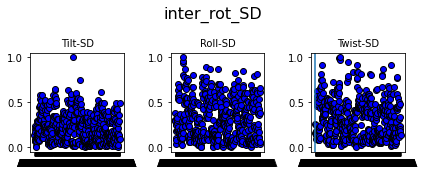

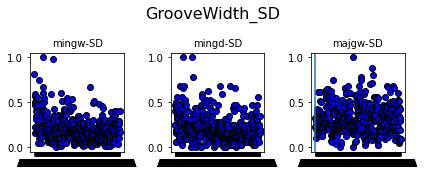

In [214]:
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)

# fig, axs = plt.subplots(1, 3, tight_layout=True)

# # N is the count in each bin, bins is the lower-limit of the bin

for i in range(len(All_params)):
    pic_index = All_params[i]
    fig = plt.figure()
    fig.suptitle(All_params_names[i], fontsize=16)

    for j in range(len(pic_index)):

        # Set up the plot
        row = len(All_params[i])/3
        ax = plt.subplot(2, 3, j+1)
    
        # Draw the plot
        x = all_norm_shape_vals[pic_index[j]]
        ax.scatter(tb.keys(), x,
                 color = 'blue', edgecolor = 'black')
    
        # Title and labels
        ax.set_title('%s' % AllDNAshape[pic_index[j]], size = 10)
    plt.axvline(x='AAAAA')
    plt.tight_layout()
    plt.show()
#     plt.savefig(All_params_names[i]+"_scatter.jpg")

In [34]:
print(DNAshape[3:5])

['Buckle', 'Propel']
